In [2]:
pip install pandas numpy matplotlib joblib seaborn scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
from datetime import datetime

from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [4]:
df=pd.read_csv("uber.csv")
print("Rows:",df.shape[0])
df.head()

Rows: 200000


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [5]:
essential_cols=['pickup_datetime','pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','fare_amount']
df=df.dropna(subset=essential_cols)
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'],errors='coerce')
df=df.dropna(subset=['pickup_datetime'])
for col in['pickup_longitude','pickup_latitude','dropoff_longitude','dropoff_latitude','fare_amount']:
    df[col]=pd.to_numeric(df[col],errors='coerce')

df=df.dropna(subset=['fare_amount'])
df=df[(df['fare_amount']>0)&(df['fare_amount']<1000)]
print("Cleaned data shape:",df.shape)
df.head()

Cleaned data shape: (199977, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


In [6]:
def haversine_distance(lat1,lon1,lat2,lon2):
    lat1,lon1,lat2,lon2=map(np.radians,[lat1,lon1,lat2,lon2])
    dlat=lat2-lat1
    dlon=lon2-lon1
    a=np.sin(dlat/2.0)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c=2*np.arcsin(np.sqrt(a))
    return 6371*c
df['distance_km']=haversine_distance(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])

df['hour']=df['pickup_datetime'].dt.hour
df['weekday']=df['pickup_datetime'].dt.weekday
df['month']=df['pickup_datetime'].dt.month
df['is_weekend']=df['weekday'].isin([5,6]).astype(int)

if 'passenger_count' in df.columns:
    df['passenger_count']=pd.to_numeric(df['passenger_count'],errors='coerce').fillna(1).astype(int)
else:
    df['passenger_count']=1
df=df[(df['distance_km']>0)&(df['distance_km']<500)]
df.head()


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,weekday,month,is_weekend
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,19,3,5,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,20,4,7,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,21,0,8,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,8,4,6,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,17,3,8,0


In [7]:
def iqr_bounds(series,k=1.5):
    q1=series.quantile(0.25)
    q3=series.quantile(0.75)
    iqr=q3-q1
    return q1-k*iqr,q3+k*iqr
fare_low,fare_high=iqr_bounds(df['fare_amount'])
dist_low,dist_high=iqr_bounds(df['distance_km'])
print("Fare IQR Bounds:",fare_low,fare_high)
print("Distance IQR Bounds:",dist_low,dist_high)
df=df[(df['fare_amount']>=fare_low)&(df['fare_amount']<=fare_high)]
df=df[(df['distance_km']>=dist_low)&(df['distance_km']<=dist_high)]
print("After removing outliers:",df.shape)


Fare IQR Bounds: -3.75 22.25
Distance IQR Bounds: -2.709825407822608 7.929915015051174
After removing outliers: (174377, 14)


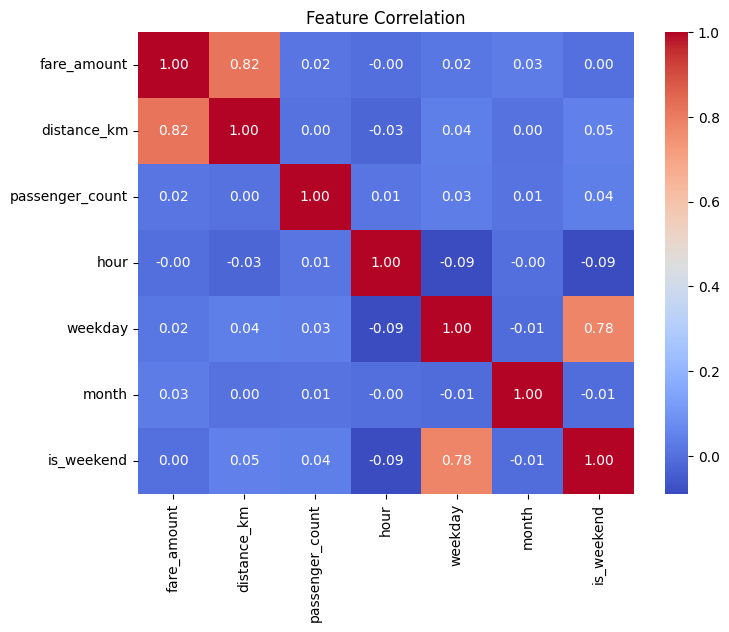

fare_amount        1.000000
distance_km        0.817211
month              0.029552
weekday            0.018060
passenger_count    0.015989
is_weekend         0.003164
hour              -0.002793
Name: fare_amount, dtype: float64

In [8]:
corr_cols=['fare_amount','distance_km','passenger_count','hour','weekday','month','is_weekend']
corr=df[corr_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Feature Correlation")
plt.show()
corr['fare_amount'].sort_values(ascending=False)

In [9]:
features=['distance_km','passenger_count','hour','weekday','month','is_weekend']
X=df[features]
y=df['fare_amount']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Train shape :",X_train.shape,"Test shape :",X_test.shape)

Train shape : (139501, 6) Test shape : (34876, 6)


In [10]:
from math import sqrt

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression → R2: {r2_lr:.3f}, RMSE: {rmse_lr:.3f}, MAE: {mae_lr:.3f}")


Linear Regression → R2: 0.663, RMSE: 2.295, MAE: 1.642


In [11]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Best Random Forest Params:", grid.best_params_)
print(f"Random Forest → R2: {r2_rf:.3f}, RMSE: {rmse_rf:.3f}, MAE: {mae_rf:.3f}")


Best Random Forest Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest → R2: 0.685, RMSE: 2.219, MAE: 1.580


In [15]:
results=pd.DataFrame({
    'Model':['Linear Regression','Random Forest'],'R2':[r2_lr,r2_rf],'RMSE':[rmse_lr,rmse_rf],'MAE':[mae_lr,mae_rf]})
results

,Model,R2,RMSE,MAE
0,Linear Regression,0.662728,2.295323,1.641816
1,Random Forest,0.684900,2.218596,1.579766


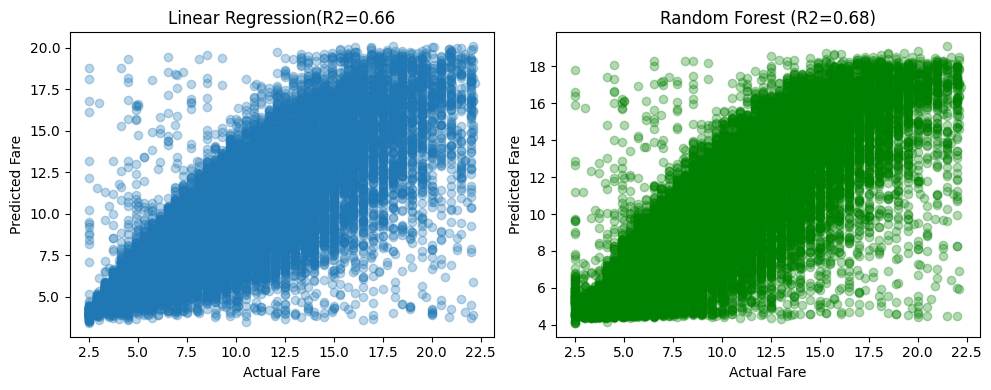

In [16]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(y_test,y_pred_lr,alpha=0.3)
plt.title(f"Linear Regression(R2={r2_lr:.2f}")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.subplot(1,2,2)
plt.scatter(y_test,y_pred_rf,alpha=0.3,color='green')
plt.title(f"Random Forest (R2={r2_rf:.2f})")
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.tight_layout()
plt.show()